(solving-systems-using-irk-methods-section)=

# Solving Systems of ODEs using IRK Methods

On the previous page we saw that to solve a single ODE using an IRK method, we need to recast the stage value expressions as a linear system which is solved at each step of the method. When we have a system of multiple ODEs, this becomes more complicated as we need to do this for each equation in the system, and the stage values may form non-linear equations. 

Consider the solution of the IVP of the form

$$\mathbf{y}' = f(t, \mathbf{y}), \qquad t \in [t_0, t_{\max}], \qquad \mathbf{y}(0) = \mathbf{y}_0, $$

where

$$ \begin{align*}
    \mathbf{y} &= \begin{pmatrix} y_1 \\ \vdots \\ y_N \end{pmatrix}, &
    f(t, \mathbf{y}) &= \begin{pmatrix} f_1(t, \mathbf{y}) \\ \vdots \\ f_N(t, \mathbf{y}) \end{pmatrix}.
\end{align*} $$

Recall that the general form of a Runge-Kutta method for solving a system of ODEs is

$$ \begin{align*}
   \mathbf{y}_{n+1} &= \mathbf{y}_n + h \sum_{i=1}^s b_i \mathbf{k}_i,\\
   \mathbf{k}_i &= f(t_n +c_i h,\mathbf{y}_n + h \sum_{j=1}^s a_{ij} \mathbf{k}_j),
\end{align*} $$(general-irk-system)

In a similar approach to solving single ODEs, we introduce an $N \times 1$ vector $\mathbf{Y}_i$ for the second parameter in $f(t, y)$ in the stage value expressions

$$\mathbf{Y}_i = \mathbf{y}_n + h \displaystyle\sum_{j=1}^s a_{ij} \mathbf{k}_j, $$(irk-Yi)

and the expression for the stage values $\mathbf{k}_i$ becomes

$$\mathbf{k}_i = f(t_n + c_ih, \mathbf{Y}_i). $$

Substituting this into equation {eq}`irk-Yi` we have

$$ \begin{align*}
    \mathbf{Y}_i = \mathbf{y}_n + h \sum_{j = 1}^s a_{ij} f(t_n + c_j h, \mathbf{Y}_j). 
\end{align*} $$(irk-Yi-2)

and also into equation {eq}`general-irk-system` gives

$$ \begin{align*}
   \mathbf{y}_{n+1} &= \mathbf{y}_n + h \sum_{i=1}^s b_i f(t_n + c_i h, \mathbf{Y}_i).
\end{align*} $$(irk-yn+1)

Using an $s$-stage IRK method, the values of $\mathbf{Y}_i$ given by equation {eq}`irk-Yi-2` are

$$ \begin{align*}
    \mathbf{Y}_1 &= \mathbf{y}_n + h (a_{11} f(t_n + c_1h, \mathbf{Y}_1) + \cdots + a_{1s} f(t_n + c_s h, \mathbf{Y}_s)), \\
    \vdots \\
    \mathbf{Y}_s &= \mathbf{y}_n + h (a_{s1} f(t_n + c_1h, \mathbf{Y}_1) + \cdots + a_{ss} f(t_n + c_s h, \mathbf{Y}_s)).
\end{align*}$$(irk-Yi-3)

Writing this as a matrix equation

$$ \begin{align*}
    \begin{pmatrix} \mathbf{Y}_1 \\ \vdots \\ \mathbf{Y}_s \end{pmatrix}
    =
    \begin{pmatrix} \mathbf{y}_n \\ \vdots \\ \mathbf{y}_n \end{pmatrix} + 
    \begin{pmatrix}
        h a_{11} f(t_n + c_1h, \mathbf{Y}_1) + \cdots + h a_{1s} f(t_n + c_sh, \mathbf{Y}_s) \\
        \vdots \\
        h a_{s1} f(t_n + c_1h, \mathbf{Y}_1) + \cdots + h a_{ss} f(t_n + c_sh, \mathbf{Y}_s) \\
    \end{pmatrix}.
\end{align*} $$(irk-Yi-matrix-form-1)

Since $\mathbf{Y}_i$ are $N \times 1$ vectors then these are $sN \times 1$ vectors. We can replace the summation with matrix multiplications using a **Kronecker product**.

```{prf:definition} The Kronecker product
:label: kronecker-definition

The <a href="https://en.wikipedia.org/wiki/Kronecker_product" target="_blank">Kronecker product</a> between an $m \times n$ matrix $A$ and another $p \times q$ matix $B$ is denoted by $A \otimes B$ and defined by

$$ \begin{align*} 
    A \otimes B =
    \begin{pmatrix} 
        a_{11} B & \cdots & a_{1n} B \\
        \vdots & \ddots & \vdots \\
        a_{m1} B & \cdots & a_{mn} B
    \end{pmatrix}.
\end{align*} $$

In other words, each element of $A$ is multiplied by the matrix $B$.
```

For example, for a 2-stage method

$$ \begin{align*}
    \begin{pmatrix} \mathbf{Y}_1  \\ \mathbf{Y}_2 \end{pmatrix}
    &= 
    \begin{pmatrix} \mathbf{y}_n \\ \mathbf{y}_n \end{pmatrix} + h
    \begin{pmatrix}
        a_{11} f(t_n + c_1h, \mathbf{Y}_1) + a_{12} f(t_n + c_2h, \mathbf{Y}_2) \\
        a_{21} f(t_n + c_1h, \mathbf{Y}_1) + a_{22} f(t_n + c_2h, \mathbf{Y}_2)
    \end{pmatrix},
\end{align*} $$

Let's say we have a system of $N = 3$ ODEs. Introducing a notation where $y_{j}$, $Y_{i,j}$ and $f_{i,j}$ are the $j$-th elements of $\mathbf{y}_n$, $\mathbf{Y}_i$ and $f(t_n + c_ih, \mathbf{Y}_i)$ respectively, then this can be written as

$$ \begin{align*}
    \begin{pmatrix} Y_{1,1} \\ Y_{1,2} \\ Y_{1,3} \\ Y_{2,1} \\ Y_{2,2} \\ Y_{2,3}  \end{pmatrix}
    &= 
    \begin{pmatrix} y_{1} \\ y_{2} \\ y_{3} \\ y_{1} \\ y_{2} \\ y_{3}  \end{pmatrix} + h
    \begin{pmatrix}
        a_{11} f_{1,1} + a_{12} f_{2,1} \\
        a_{11} f_{1,2} + a_{12} f_{2,2} \\
        a_{11} f_{1,3} + a_{12} f_{2,3} \\
        a_{21} f_{1,1} + a_{22} f_{2,1} \\
        a_{21} f_{1,2} + a_{22} f_{2,2} \\
        a_{21} f_{1,3} + a_{22} f_{2,3}
    \end{pmatrix} \\
    &=
    \begin{pmatrix} y_{1} \\ y_{2} \\ y_{3} \\ y_{1} \\ y_{2} \\ y_{3}  \end{pmatrix} + h
    \begin{pmatrix} 
        a_{11} & 0 & 0 & a_{12} & 0 & 0 \\
        0 & a_{11} & 0 & 0 & a_{12} & 0 \\
        0 & 0 & a_{11} & 0 & 0 & a_{12} \\
        a_{21} & 0 & 0 & a_{22} & 0 & 0 \\
        0 & a_{21} & 0 & 0 & a_{22} & 0 \\
        0 & 0 & a_{21} & 0 & 0 & a_{22}
    \end{pmatrix}
    \begin{pmatrix}
        f_{1,1} \\
        f_{1,2} \\
        f_{1,3} \\
        f_{2,1} \\
        f_{2,2} \\
        f_{2,3}
    \end{pmatrix}
\end{align*} $$

The $6\times 6$ matrix is $A \otimes I_N$ so we can write the expression for the stage values $\mathbf{Y}_i$ as

$$ \mathbf{Y} = \mathbf{e} \otimes \mathbf{y}_n + h (A \otimes I_N) F(\mathbf{Y}), $$(irk-Yi-matrix-form-2)

where $\mathbf{e} = (1, \ldots, 1)^\mathsf{T} \in \mathbb{R}^s$

$$ \begin{align*}
    \mathbf{Y} &= \begin{pmatrix} \mathbf{Y}_1 \\ \vdots \\ \mathbf{Y}_s \end{pmatrix}, &
    F(\mathbf{Y}) &= \begin{pmatrix} f(t_n + c_1h, \mathbf{Y}_1) \\ \vdots \\ f(t_n + c_s h, \mathbf{Y}_s) \end{pmatrix}.
\end{align*} $$

We can also use a Kronecker product to simplify the expression for the summation in {eq}`irk-yn+1`

$$ \mathbf{y}_{n+1} = \mathbf{y}_n + h (\mathbf{b}^\mathsf{T} \otimes I_N) F(\mathbf{Y}). $$(irk-matrix-form)

---

## Newton's method

To compute the stage values $\mathbf{Y}_1, \ldots, \mathbf{Y}_s$​, we must solve the system given in equation {eq}`irk-Yi-matrix-form-2`. Unlike the examples in the previous page, this system is generally nonlinear because the function $f(t,\mathbf{y})$ may contain nonlinear terms. This means we cannot rearrange the equations into a linear system and solve them directly. To solve these equations we use  <a href="https://en.wikipedia.org/wiki/Newton%27s_method" target="_blank">Newton's method</a>, which is a well known numerical method to computing the solutions of $g(x) = 0$ where $g$ is a differentiable function. 

### Newton's method for a single equation

Suppose we wish to solve

$$ g(x) = 0. $$

Starting from an initial guess value $x^{(0)}$, Newton's method repeatedly improves the estimate using

$$x^{(k+1)} = x^{(k)} - \frac{g(x^{(k)})}{g'(x^{(k)})}. $$

The iterations continue until successive estimates differ by less than a specified tolerance.

### Newton's method for a system of equations

Given a system of equations $g(\mathbf{x}) = \mathbf{0}$ where $g = (g_1, g_2, \ldots)$ are differentiable functions, then the matrix form of Newton's method is 

$$\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} - J^{-1}g(\mathbf{x}^{(k)}),$$

where $J$ is the Jacobian matrix 

$$ \begin{align*}
    J = \frac{\partial g}{\partial \mathbf{x}} = 
    \begin{pmatrix}
        \dfrac{\partial g_1}{\partial x_1} & \cdots & \dfrac{\partial g_1}{\partial x_N} \\
        \vdots & \ddots & \vdots \\
        \dfrac{\partial g_N}{\partial x_1} & \cdots & \dfrac{\partial g_N}{\partial x_N}
    \end{pmatrix}.
\end{align*} $$

Rather than computing the inverse $J^{-1}$, which is expensive and unnecessary, we solve the linear system

$$J \Delta x = -g(\mathbf{x}^{(k)}), $$

where 

$$ \Delta \mathbf{x} = \mathbf{x}^{(k + 1)} - \mathbf{x}^{(k)}. $$

Once $\Delta \mathbf{x}$ has been found, the estimate is improved using 

The improved estimate is then calculated using 

$$ \mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} + \Delta \mathbf{x}. $$

This process is repeated until

$$ \| \Delta \mathbf{x} \| < tol.$$

### Computing the stage values using Newton's method

For an $s$-stage IRK method applied to a system of $N$ ODEs, the unknown vector 

$$ \mathbf{Y} = \begin{pmatrix} \mathbf{Y}_1 \\ \vdots \\ \mathbf{Y}_2 \end{pmatrix}, $$

contains $sN$ unknowns. We rewrite the stage equations {eq}`irk-Yi-matrix-form-2` as

$$ g(\mathbf{Y}) = \mathbf{Y} - \mathbf{e} \otimes \mathbf{y}_n - h(A \otimes I_N) F(\mathbf{Y}),$$(g-jacobian-1)

The Jacobian matrix is

$$ \begin{align*}
    J_g &= \frac{\partial g}{\partial \mathbf{Y}} = I_{sN} - h(A \otimes I_N) F'(\mathbf{Y}),
\end{align*} $$

where 

$$ F'(\mathbf{Y}) = \begin{pmatrix}
    J_f^{(1)} & 0 & \cdots & 0 \\
    0 & J_f^{(2)} & \ddots & \vdots \\
    \vdots & \ddots & \ddots & 0 \\
    0 & \cdots & 0 & J_f^{(s)}
\end{pmatrix}$$

and

$$ J_f^{(i)} = \frac{\partial}{\partial \mathbf{y}} f(t_n + c_ih, \mathbf{Y}_i).$$

Each Jacobian $J_f^{(i)}$ is an $N \times N$ matrix so $J_g$ is a $sN \times sN$ matrix

$$ \begin{align*}
    J_g &= I_{sN} - h
    \begin{pmatrix}
        a_{11} J_f^{(1)} & 
        \cdots & 
        a_{1s} J_f^{(s)} \\ 
        \vdots & \ddots & \vdots \\
        a_{s1} J_f^{(1)} & 
        \cdots & 
        a_{ss} J_f^{(s)}
    \end{pmatrix}
\end{align*} $$

Computing $J_f^{(1)}, \ldots, J_f^{(s)}$ at every Newton iteration can be expensive. A common simplification is 

$$ J_f^{(i)} \approx \frac{\partial}{\partial \mathbf{y}} f(t_n, \mathbf{y}_n)$$

so equation {eq}`g-jacobian-1` becomes

$$ J_g = I_{sN} - h (A \otimes J_f) $$

### Computing $J_f$

The individual $J_f$ Jacobians can be computed using a finite difference approximation

$$ J_{f}^{(i)} = \frac{\partial f}{\partial \mathbf{y}_i} \approx \frac{f(t_n, \mathbf{y}_n + \epsilon \, \mathbf{e}_i) - f(t_n, \mathbf{y}_n)}{\epsilon \,},$$

where $\mathbf{\epsilon}$ is some small value and $\mathbf{e}_i$ is column $i$ of $I_s$. For example, consider a system of two ODEs

$$ \begin{align*}
    f(t, \mathbf{y}) = \begin{pmatrix} f_1(t, y_1, y_2) \\ f_2(t, y_1, y_2) \end{pmatrix}.
\end{align*} $$

The Jacobian is 

$$ J_f = \begin{pmatrix}
    \dfrac{\partial f_1}{\partial y_1} & \dfrac{\partial f_1}{\partial y_2} \\
    \dfrac{\partial f_2}{\partial y_1} & \dfrac{\partial f_2}{\partial y_2}
\end{pmatrix}. $$

To approximate the first column, we only perturb $y_1$

$$ \frac{\partial f}{\partial y_1} \approx \frac{f(t, \mathbf{y} + \epsilon \, \mathbf{e}_1) - f(t, \mathbf{y})}{\epsilon \,}, $$

where 

$$ \mathbf{y} + \epsilon \, \mathbf{e}_1 = \begin{pmatrix} y_1 \\ y_2 \end{pmatrix} + \epsilon \, \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} y_1 + \epsilon \, \\ y_2 \end{pmatrix}. $$

To approximate the second column, we only perturb $y_2$

$$ \frac{\partial f}{\partial y_2} \approx \frac{f(t, \mathbf{y} + \epsilon \, \mathbf{e}_2) - f(t, \mathbf{y})}{\epsilon \,}, $$

where

$$ \mathbf{y} + \epsilon \, \mathbf{e}_2 = \begin{pmatrix} y_1 \\ y_2 \end{pmatrix} + \epsilon \, \begin{pmatrix} 0 \\ 1 \end{pmatrix} = \begin{pmatrix} y_1 \\ y_2 + \epsilon \, \end{pmatrix}. $$

The Jacobian matrix $J_f$ is constant for all Newton iterations, so the solution of the linear system is well suited to [LU decomposition](lu-section).

---

## Applying an IRK to solve a system of ODEs

The steps used to solve an IVP using an IRK method are outlined in {prf:ref}`irk-algorithm`.

```{prf:algorithm} Solving an IVP using an IRK method
:label: irk-algorithm

**Inputs** A system of first-order ODEs of the form $\mathbf{y}' = f(t, \mathbf{y})$, a domain $t \in [t_0, t_{\max}]$, a vector of initial values $\mathbf{y}(t_0) = y_0$ and a value of the step length $h$

**Outputs** $(t_0, t_1, \ldots)$ and $(\mathbf{y}_0, \mathbf{y}_1, \ldots)$.

- $nsteps \gets \left\lfloor \dfrac{t_{\max} - t_0}{h} \right\rfloor$
- For $n = 0, \ldots, nsteps$
    - $J_f \gets \dfrac{\partial}{\partial \mathbf{y}} f(t_n, \mathbf{y}_n)$
    - $\mathbf{Y} \gets \mathbf{e} \otimes \mathbf{y}_n$
    - For $k = 1, \ldots, maxiter$
        - $g(\mathbf{Y}) \gets \mathbf{Y} - \mathbf{e} \otimes \mathbf{y}_n - h (A \otimes I_N) F(\mathbf{Y})$
        - Solve the linear system $(I - h (A \otimes J_f)) \Delta \mathbf{Y} = -g(\mathbf{Y})$ for $\Delta \mathbf{Y}$
        - $\mathbf{Y} \gets \mathbf{Y} + \Delta \mathbf{Y}$
        - If $\| \Delta \mathbf{Y} \| < tol$
            - break
    - $\mathbf{y}_{n+1} \gets \mathbf{y}_n + h (\mathbf{b}^T \otimes I_N) F(\mathbf{Y})$
    - $t_{n+1} \gets t_n + h$
- Return $(t_0, t_1, \ldots)$ and $(\mathbf{y}_0, \mathbf{y}_1, \ldots)$
```

The additional cost of solving an $sN$-dimensional nonlinear system at every step is compensated by the excellent stability properties of IRK methods, making them particularly effective for stiff systems of ODEs.

````{prf:example}

The van der Pol oscillator is a well known model of an oscillating system with non-linear damping described by the second-order ODE

$$ \ddot{y} - \mu (1 - y^2) \dot{y} + y = 0, $$

where $\mu$ is a scalar parameter that governs the strength of the damping. 

Use the Radau IA method to compute the solution to the van der Pol oscillator over the first 50 seconds where $y(0) = 2$ and $\mu = 10$. 

---

**Solution**

We need to rewrite the second-order ODE as a system of first-order ODEs. Let $y_1 = y$ and $y_2 = \dot{y}_1$ then

$$ \begin{align*}
    \dot{y}_1 &= y_2, \\
    \dot{y}_2 &= \mu (1 - y_1^2) y_2 - y_1,
\end{align*} $$

so 

$$ \begin{align*}
    \mathbf{y}&= \begin{pmatrix} y_1 \\ y_2 \end{pmatrix}, &
    f(t, \mathbf{y}) &= \begin{pmatrix} y_2 \\ \mu (1 - y_1^2) y_2 - y_1 \end{pmatrix}.
\end{align*} $$

The initial conditions are $\mathbf{y}_0 = (2, 0)$ and $\mu = 10$. The Jacobian matrix is

$$ \begin{align*} 
    J_f &= 
    \begin{pmatrix}
        0 & 1 \\
        -2\mu y_1y_2 - 1 & \mu(1 - y_1^2)
    \end{pmatrix}
    =
    \begin{pmatrix}
        0 & 1 \\
        -1 & -30 
    \end{pmatrix}.
\end{align*} $$

The coefficients for the Radau IA method are

$$ \begin{align*}
    A &= \begin{pmatrix} \frac{1}{4} & -\frac{1}{4} \\ \frac{1}{4} & \frac{5}{12} \end{pmatrix}, &
    \mathbf{b} &= \begin{pmatrix} \frac{1}{4} \\ \frac{3}{4} \end{pmatrix} &
    \mathbf{c} &= \begin{pmatrix} 0 \\ \frac{2}{3} \end{pmatrix}.
\end{align*} $$

Using Newton's method to solve for $\mathbf{Y}$

$$ \begin{align*}
    \mathbf{Y} &= \mathbf{e} \otimes \mathbf{y}_0 = \begin{pmatrix} 1 \\ 1 \end{pmatrix} \otimes \begin{pmatrix} 2 \\ 0 \end{pmatrix}= \begin{pmatrix} 2 \\ 0 \\ 2 \\ 0 \end{pmatrix}, &
    F(\mathbf{Y}) &= 
    \begin{pmatrix}
        f(t_0 + 0h, \mathbf{Y}_1) \\
        f(t_0 + \frac{2}{3}h, \mathbf{Y}_2)
    \end{pmatrix}
    =
    \begin{pmatrix} 0 \\ -2 \\ 0 \\ -2 \end{pmatrix}
\end{align*} $$

and

$$ \begin{align*}
    g(\mathbf{Y}) &= \mathbf{Y} - \mathbf{e} \otimes \mathbf{y}_n - h(A \otimes I_2) F(\mathbf{Y}) \\
    &= 
    \begin{pmatrix} 0 \\ 0 \\ 0 \\ 0 \end{pmatrix} -
    \begin{pmatrix} 2 \\ 0 \\ 2 \\ 0 \end{pmatrix} -
    \begin{pmatrix} 
        \frac{1}{4} & 0 & -\frac{1}{4} & 0 \\
        0 & \frac{1}{4} & 0 & -\frac{1}{4} \\
        \frac{1}{4} & 0 & \frac{5}{12} & 0 \\
        0 & \frac{1}{4} & 0 & \frac{5}{12}
    \end{pmatrix}
    \begin{pmatrix} 0 \\ -2 \\ 0 \\ -2 \end{pmatrix}
    =
    \begin{pmatrix} 0 \\ 0 \\ 0 \\ \frac{4}{3} \end{pmatrix}.
\end{align*} $$

Solving $(I_4 - h(A \otimes J_f))\Delta \mathbf{Y} = -g(\mathbf{Y})$ for $\Delta \mathbf{Y}$ gives

$$ \begin{align*}
    \Delta \mathbf{Y}
    &=\begin{pmatrix} 0.0007 \\ -0.0222 \\ -0.0027 \\ -0.0518 \end{pmatrix},
\end{align*} $$

so the new estimate of $\mathbf{Y}$ is

$$ \begin{align*}
    \mathbf{Y} &= \mathbf{Y} + \Delta \mathbf{Y}
    =
    \begin{pmatrix} 2 \\ 0 \\ 2 \\ 0 \end{pmatrix} +
    \begin{pmatrix} 0.0007 \\ -0.0222 \\ -0.0027 \\ -0.0518 \end{pmatrix}
    =
    \begin{pmatrix} 2.0007 \\ -0.0222 \\ 1.9973 \\ -0.0518 \end{pmatrix}
\end{align*}. $$

Here $\|\Delta \mathbf{Y}\| = 0.056447$ so we need to continue iterating. After just one more iteration, $\mathbf{Y}$ converges to the solution

$$ \begin{align*}
    \mathbf{Y} &= \begin{pmatrix} 2.0007 \\ -0.0222 \\ 1.9973 \\ -0.0519 \end{pmatrix}, &
    F(\mathbf{Y}) &= \begin{pmatrix} -0.0222 \\ -1.3339 \\ -0.0519 \\ -0.4456 \end{pmatrix}.
\end{align*} $$

Calculating $\mathbf{y}_{1}$

$$ \begin{align*}
    \mathbf{y}_1 &= \mathbf{y_0} + h(\mathbf{b}^\mathsf{T} \otimes I_2) F(\mathbf{Y}) \\
    &= 
    \begin{pmatrix} 2 \\ 0 \end{pmatrix} + 0.1
    \begin{pmatrix}
        \frac{1}{4} & 0 & \frac{3}{4} & 0 \\
        0 & \frac{1}{4} & 0 & \frac{3}{4} 
    \end{pmatrix}
    \begin{pmatrix} -0.0222 \\ -1.3339 \\ -0.0519 \\ -0.4456 \end{pmatrix}
    = \begin{pmatrix} 1.9956 \\ -0.0667 \end{pmatrix}.
\end{align*} $$

The solution over the full domain $t \in [0, 50]$ is shown in {numref}`vanderpol-plot-figure`.

```{glue:figure} vanderpol_plot
:name: vanderpol-plot-figure

Solution of the van der Pol oscillator where $\mu=10$ using the Radau IA IRK method.
```
````

---

## Code

The code below defines the functions `jac()` and `radauIA()` which computes the Jacobian of a function $f(t, y)$ and the solution to an initial value problem using the Radau IA method respectively.

`````{tab-set}
````{tab-item} Python
```python
def jac(f, t, y):
    N = len(y)
    J = np.zeros((N, N))
    I = np.eye(N)
    epsilon = 1e-6
    
    for i in range(N):
        J[:,i] = (f(t, y + epsilon * I[:,i]) - f(t,y)) / epsilon

    return J


def radauIA(f, tspan, y0, h):
    
    # Determine the number of ODEs in the system
    N = len(y0)

    # Calculate the number of steps required
    nsteps = int((tspan[1] - tspan[0]) / h)

    # Define solution arrays and assign initial values
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Define Butcher tableau
    A = np.array([[1/4, -1/4],
                  [1/4, 5/12]])
    b = np.array([1/4, 3/4])
    c = np.array([0, 2/3])
    s = 2

    # Define maximum Newton iterations
    max_iter = 10

    # Loop through steps
    for n in range(nsteps):

        # Use Newton's method to solve for the stage values
        e = np.ones(s)
        Y = np.kron(e, y[n,:])
        F = np.zeros(N * s)
        J = jac(f, t[n], y[n,:])

        for k in range(max_iter):
            F[:N] = f(t[n] + c[0] * h, Y[:N])
            F[N:] = f(t[n] + c[1] * h, Y[N:])
            g = Y - np.kron(e, y[n,:]) - h * np.kron(A, np.eye(N)) @ F
            delta_Y = np.linalg.solve(np.eye(N * s) - h * np.kron(A, J), -g)
            Y += delta_Y

            if np.linalg.norm(delta_Y) < 1e-6:
                break

        y[n+1,:] = y[n,:] + h * np.kron(b.T, np.eye(N)) @ F
        t[n+1] = t[n] + h

    return t, y
```

This code uses the following NumPy functions:

- `np.eye(N)` -- returns $I_N$
- `np.kron(A, B)` -- returns the Kronecker product $A \otimes B$
- `np.linalg.solve(A, b)` -- returns the solution to the linear system $A \mathbf{x} = \mathbf{b}$
- `np.eye(n)` -- returns the $n \times n$ identity matrix
- `np.linalg.norm(a)` -- returns the Euclidean norm of the vector $\mathbf{a}$
````

````{tab-item} MATLAB
```matlab
function J = jac(f, t, y)

N = length(y);
J = zeros(N, N);
I = eye(N);
epsilon = 1e-6;

for i = 1 : N
    J(:, i) = (f(t, y + epsilon * I(:,i)) - f(t, y)) / epsilon;
end

end

function [t, y] = radauIA(f, tspan, y0, h)

% Determine the number of ODEs in the system
N = length(y0);

% Calculate the number of steps required
nsteps = floor((tspan(2) - tspan(1)) / h);

% Define solution arrays and assign initial values
t = zeros(nsteps + 1, 1);
y = zeros(nsteps + 1, N);
t(1) = tspan(1);
y(1,:) = y0;

% Define Butcher tableau
A = [ 1/4, -1/4 ; 1/4, 5/12 ];
b = [ 1/4 ; 3/4 ];
c = [ 0 ; 2/3 ];
s = 2;

% Define maximum Newton iterations
max_iter = 10;

% Loop through steps
for n = 1 : nsteps

    % Use Newton's method to solve for the stage values
    e = ones(N, 1);
    Y = kron(e, y(n,:)');
    F = zeros(N * s, 1);
    J = jac(f, t(n), y(n,:)');

    for k = 1 : max_iter
        F = [f(t(n) * c(1) * h, Y(1:N)') ;
             f(t(n) * c(2) * h, Y(N+1:end)')];
        g = Y - kron(e, y(n,:)') - h * kron(A, eye(N)) * F;
        delta_Y = (eye(N * s) - h * kron(A, J)) \ -g;
        Y = Y + delta_Y;

        if norm(delta_Y) < 1e-6
            break
        end
    end

    y(n+1,:) = y(n,:) + (h * kron(b', eye(N)) * F)';
    t(n+1) = t(n) + h;
end

end
```

This code uses the following functions:

- `eye(N)` -- returns $I_N$
- `kron(A, B)` -- returns the Kronecker product $A \otimes B$
- `A \ b` -- returns the solution to the linear system $A \mathbf{x} = \mathbf{b}$
- `eye(n)` -- returns the $n \times n$ identity matrix
- `norm(a)` -- returns the Euclidean norm of the vector $\mathbf{a}$

````
`````

```{note}
The solution of the linear system for Newton's method in the code above was done using NumPy's and MATLAB's linear system solvers. In practice, this is done using [LU decomposition](lu-section) which is more efficient in this case since the coefficient method is constant for all iterations in a step. I used NumPy's and MATLAB's solvers here since have yet to meet LU decomposition which is covered in [chapter 6](lu-section). 
```

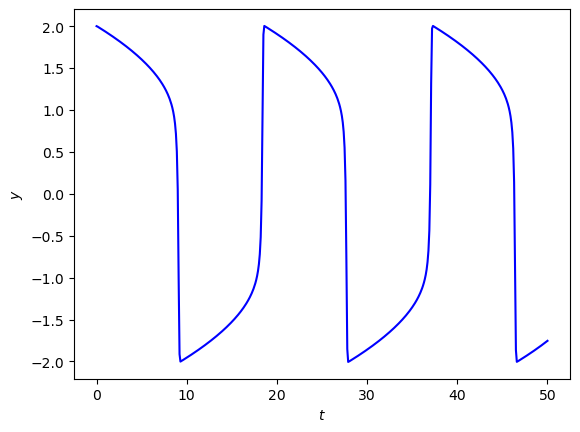

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def jac(f, t, y):
    N = len(y)
    J = np.zeros((N, N))
    I = np.eye(N)
    epsilon = 1e-6
    
    for i in range(N):
        J[:,i] = (f(t, y + epsilon * I[:,i]) - f(t,y)) / epsilon

    return J


def radauIA(f, tspan, y0, h):
    
    # Determine the number of ODEs in the system
    N = len(y0)

    # Calculate the number of steps required
    nsteps = int((tspan[1] - tspan[0]) / h)

    # Define solution arrays and assign initial values
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Define Butcher tableau
    A = np.array([[1/4, -1/4],
                  [1/4, 5/12]])
    b = np.array([1/4, 3/4])
    c = np.array([0, 2/3])
    s = 2

    # Define maximum Newton iterations
    max_iter = 10

    # Loop through steps
    for n in range(nsteps):

        # Use Newton's method to solve for the stage values
        e = np.ones(s)
        Y = np.kron(e, y[n,:])
        F = np.zeros(N * s)
        J = jac(f, t[n], y[n,:])

        for k in range(max_iter):
            F[:N] = f(t[n] + c[0] * h, Y[:N])
            F[N:] = f(t[n] + c[1] * h, Y[N:])
            g = Y - np.kron(e, y[n,:]) - h * np.kron(A, np.eye(N)) @ F
            delta_Y = np.linalg.solve(np.eye(N * s) - h * np.kron(A, J), -g)
            Y += delta_Y

            if np.linalg.norm(delta_Y) < 1e-6:
                break

        y[n+1,:] = y[n,:] + h * np.kron(b.T, np.eye(N)) @ F
        t[n+1] = t[n] + h

    return t, y


# Define van der Pol system
def vanderpol(t, y):
    return np.array([y[1], mu * (1 - y[0] ** 2) * y[1] - y[0]])


# Setup IVP
tspan = [0, 50]
y0 = [2, 0]
h = 0.1
mu = 10

# Solve IVP
t, y = radauIA(vanderpol, tspan, y0, h)

# Plot solution 
fig, ax = plt.subplots()
plt.plot(t, y[:,0], 'b')
plt.xlabel('$t$')
plt.ylabel('$y$')
plt.show()


from myst_nb import glue
glue("vanderpol_plot", fig, display=False)